In [50]:
import os
import pickle
from pathlib import Path
from pprint import pprint

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, gaussian_kde

import torch
import scipy

In [51]:
experiment_folder = Path(os.path.join(Path.cwd().parent, 'experiment_data'))

In [52]:
data_files = [
    'search-data-ss-e50-r10-p0.2000-t15-n210-s512.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s300.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s256.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s128.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s64.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s32.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s16.pkl',
    'search-data-ss-e50-r10-p0.2000-t15-n210-s8.pkl',
]

In [53]:
results = []

In [54]:
for fname in data_files:
    with open(experiment_folder / fname, 'rb') as f:
        results.append(pickle.load(f)) 

In [55]:
pprint(list(results[0].keys()))

['seeds',
 'config',
 'FC-train-losses',
 'FC-train-accs',
 'FC-test-losses',
 'FC-test-accs',
 'winning-tickets',
 'winning-tickets-full-initializations',
 'winning-ticket-masks',
 'pruned-train-loss-before',
 'pruned-train-acc-before',
 'pruned-test-loss-before',
 'pruned-test-acc-before',
 'pruned-train-loss-after',
 'pruned-train-acc-after',
 'pruned-test-loss-after',
 'pruned-test-acc-after',
 'reinit-config',
 'searchexp-train-loss',
 'searchexp-train-acc',
 'searchexp-test-loss',
 'searchexp-test-acc',
 'search-hits']


In [56]:
len(results)

8

In [57]:
for r in results:
    print(r['config'])

{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 512}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 300}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 256}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 128}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 64}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 32}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 16}
{'epochs': 50, 'num_rounds': 10, 'pruning_ratio': 0.2, 'hidden_size': 8}


In [63]:
acc = []
for r in results:
    acc.append(np.array(r['searchexp-test-acc']))


In [64]:
for a in acc:
    print(a.mean())

0.9807285456430345
0.9779671189330873
0.9766780717032296
0.9700995008150737
0.9583880716846103
0.934575213988622
0.8864009309382666
0.7861966465200697


prop. weights kept: 0.1074, P[X > acc(FC)]=[0.14598992], P[X > acc(prune)]=[0.00274971], n_reps_FC = 7, n_reps_prune = 364
prop. weights kept: 0.1074, P[X > acc(FC)]=[0.05633719], P[X > acc(prune)]=[0.00012013], n_reps_FC = 18, n_reps_prune = 8324
prop. weights kept: 0.1074, P[X > acc(FC)]=[2.7485681e-06], P[X > acc(prune)]=[9.53979076e-11], n_reps_FC = 363826, n_reps_prune = 10482410207
prop. weights kept: 0.1074, P[X > acc(FC)]=[0.], P[X > acc(prune)]=[0.], n_reps_FC = ∞, n_reps_prune = ∞
prop. weights kept: 0.1074, P[X > acc(FC)]=[0.], P[X > acc(prune)]=[5.02243749e-15], n_reps_FC = ∞, n_reps_prune = 199106509841643
prop. weights kept: 0.1074, P[X > acc(FC)]=[7.68649694e-14], P[X > acc(prune)]=[3.86707111e-07], n_reps_FC = 13009827592462, n_reps_prune = 2585936
prop. weights kept: 0.1074, P[X > acc(FC)]=[0.], P[X > acc(prune)]=[0.00032132], n_reps_FC = ∞, n_reps_prune = 3112
prop. weights kept: 0.1074, P[X > acc(FC)]=[1.40041217e-10], P[X > acc(prune)]=[0.05228262], n_reps_FC = 7140

C:\Users\Sukrit\AppData\Local\Temp\ipykernel_25532\928345737.py:75: RuntimeWarning: divide by zero encountered in scalar divide
  n_reps_FC = round(1/(p_beat_og))
C:\Users\Sukrit\AppData\Local\Temp\ipykernel_25532\928345737.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  n_reps_prune = round(1/(p_beat_pn))


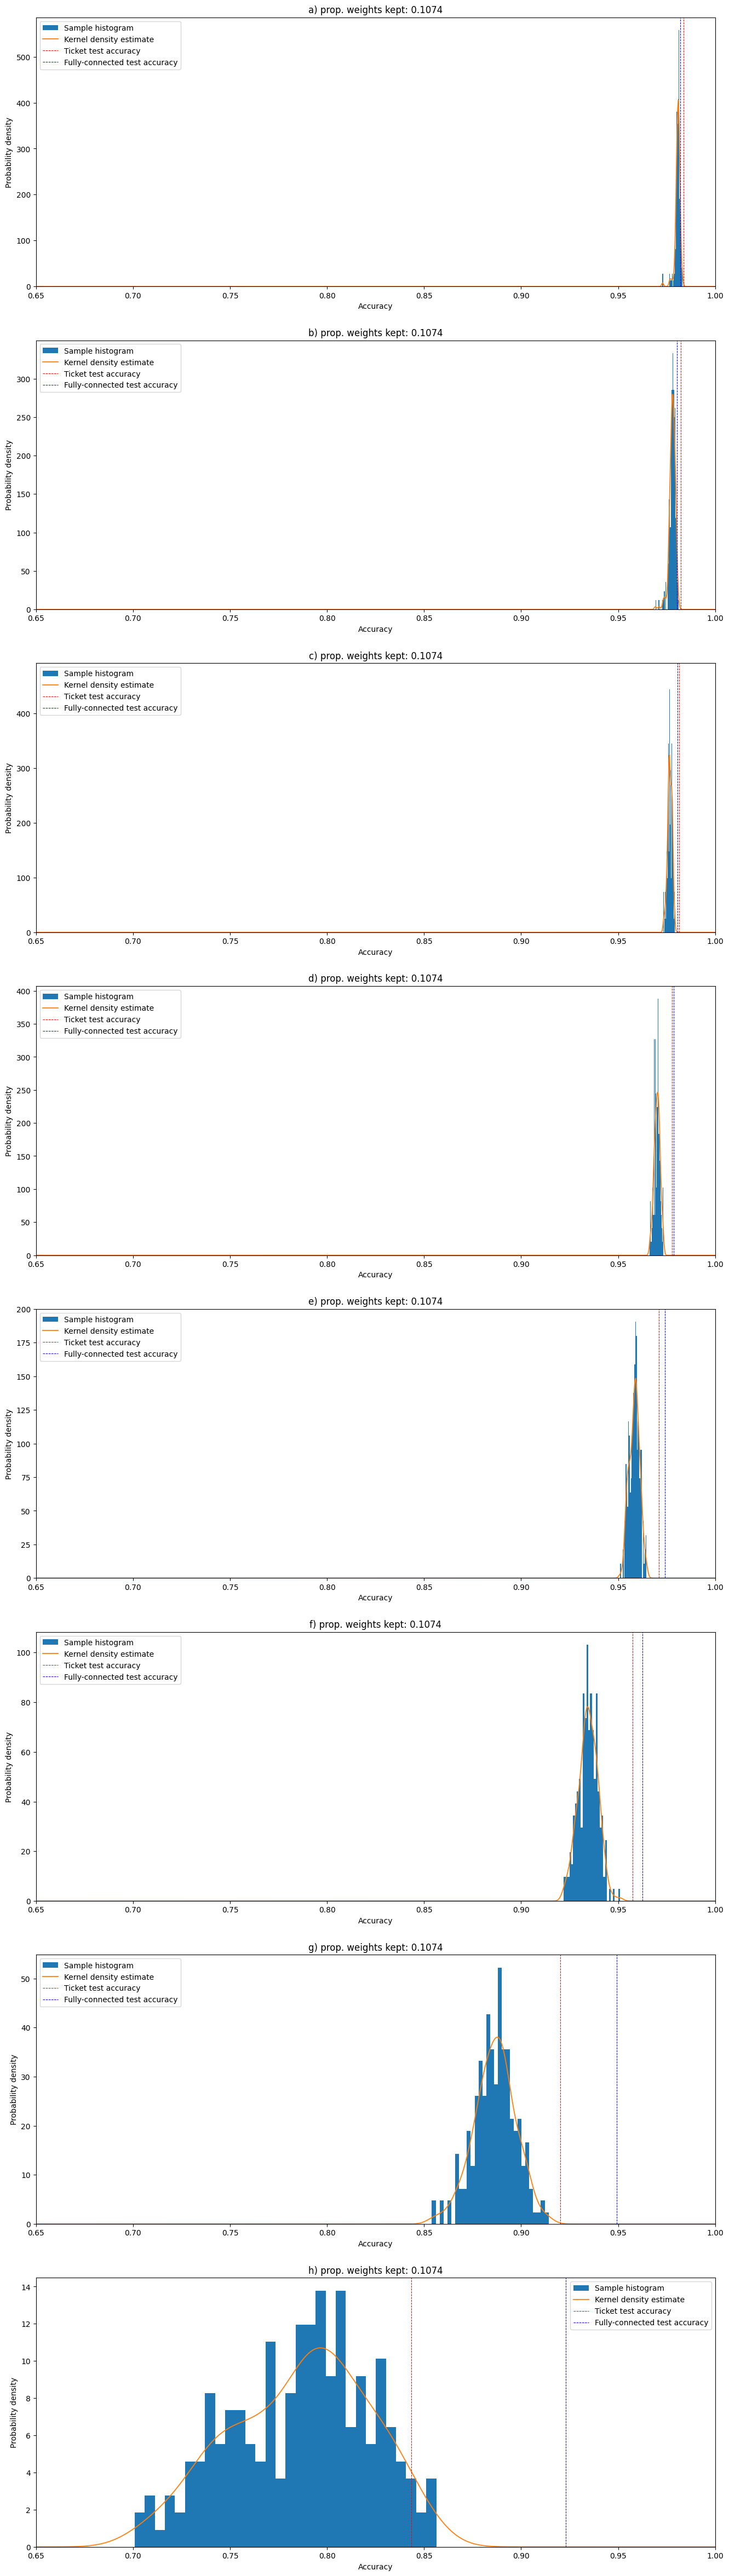

In [65]:
fig, axs = plt.subplots(len(results), 1, figsize=(16, len(results)*7.5))
# fig, axs = plt.subplots(len(results)//2, len(results)//4, figsize=(12*len(results)/2, len(results)*15/4), sharey=False)
axs = axs.T
axs = axs.flatten()

KDE = True

n_reps_prunes = []
n_reps_FCs = []
sparsities = []
mean_ticket_perfs = []
for i, ax in enumerate(axs):

    # h = np.pow(4*np.pow(acc[i].std(), 5)/3*(acc[i].shape[0]), 1/5)
    # h = 1.06*acc[i].std()*(acc[i].shape[0]**(-0.5))
    # h=0.0015
    # h = gridsearchCV_bw(acc[i], n_splits=10, bandwidth_range=(0.001, 0.05), resolution=200)
    # h = cv_bands[i]

    # kde = KernelDensity(kernel='gaussian', bandwidth=h, metric='euclidean').fit(acc[i][:, np.newaxis])
    kde_model = gaussian_kde(acc[i], bw_method='scott')
    # X_plot = np.linspace(acc[i].min()-0.02, 1., 1000)
    X_plot = np.linspace(0.65, 1., 1000)
    dens = kde_model.pdf(X_plot)

    # print(kde_model.integrate_box_1d(0, 1))

    mean = acc[i].mean()
    std = acc[i].std()
    norm_model = norm(loc=mean, scale=std)
    

    ax.set_xlim(0.65, 1.)

    ax.hist(acc[i], bins=30, density=True, label='Sample histogram')

    l_thickness = 1.3
    if KDE: ax.plot(X_plot, dens, linewidth=l_thickness, label='Kernel density estimate')
    if not KDE: ax.plot(X_plot, norm_model.pdf(X_plot), linewidth=l_thickness, label='Gaussian estimate')
    # ax.plot(X_plot, 100*norm_model.cdf(X_plot), linewidth=l_thickness)

    mean_ticket_perf = sum(results[i]['pruned-test-acc-after'])/len(results[i]['pruned-test-acc-after'])
    mean_ticket_perfs.append(mean_ticket_perf)
    mean_fc_perf =  sum(results[i]['FC-test-accs'])/len(results[i]['FC-test-accs'])

    ax.axvline(
        x=mean_ticket_perf,
        color='r',
        linestyle='--',
        label='Ticket test accuracy',
        linewidth=0.7
        )
    ax.axvline(
        x=mean_fc_perf,
        color='b',
        linestyle='--',
        label='Fully-connected test accuracy',
        linewidth=0.7
        )
    
    sparsity = (1-results[i]['config']['pruning_ratio'])**results[i]['config']['num_rounds']

    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Probability density')
    ax.legend()

    if not KDE:
        p_beat_og = 1.0 - norm_model.cdf(mean_fc_perf)
        p_beat_pn = 1.0 - norm_model.cdf(mean_ticket_perf)
    elif KDE:
        p_beat_og = kde_model.integrate_box_1d(low=mean_fc_perf, high=10000)
        p_beat_pn = kde_model.integrate_box_1d(low=mean_ticket_perf, high=10000)
    
    try:
        n_reps_FC = round(1/(p_beat_og))
    except OverflowError:
        n_reps_FC = '∞'
    
    try:
        n_reps_prune = round(1/(p_beat_pn))
    except OverflowError:
        n_reps_prune = '∞'
    
    n_reps_prunes.append(n_reps_prune)
    n_reps_FCs.append(n_reps_FC)
    sparsities.append(sparsity)

    print(f'prop. weights kept: {sparsity:.4f}, P[X > acc(FC)]={np.array([p_beat_og])}, P[X > acc(prune)]={np.array([p_beat_pn])}, n_reps_FC = {n_reps_FC}, n_reps_prune = {n_reps_prune}')

    # ax.set_title(f'prop. weights kept: {sparsity:.4f} | P[X > acc(FC)]={p_beat_og:.4f} | P[X > acc(prune)]={p_beat_pn:.4f}')
    # ax.set_title(f'prop. weights kept: {sparsity:.4f}')
    ax.set_title(f'{chr(ord('a') + i)}) prop. weights kept: {sparsity:.4f}')
    # ax.set_title(f'{chr(ord('a') + i)})')